# Mapeo Perceptual de Operadores Móviles con PROC MDS

## Resumen Ejecutivo

Un equipo de investigación de mercado de telecomunicaciones mide qué tan similares perciben los clientes a ocho operadores móviles competidores y usa **PROC MDS** para recuperar un mapa perceptual bidimensional a partir de la matriz de disimilitud. Los dos ejes latentes — calidad de red y precio/valor — se construyen deliberadamente para variar de forma *independiente*, de modo que el mapa recuperado es genuinamente bidimensional: muestra qué marcas se perciben como sustitutas, cuáles ocupan un posicionamiento distinto y qué tan bien dos dimensiones resumen el panorama competitivo.

## Fuentes de Datos

| Conjunto de Datos | Filas | Variables Clave | Descripción |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (una por operador) | `Carrier` (ID), `D1`-`D8` | Matriz cuadrada simétrica de disimilitudes percibidas entre 8 operadores móviles, en una escala de 0 a 10 (0 = percibidos idénticos, mayor = más diferentes). Generada a partir de posiciones de marca latentes en 2D sobre dos ejes *independientes* (calidad de red y precio/valor) más ruido de encuesta vía `rand('NORMAL')`. La diagonal es 0. |

# Mapeo Perceptual de Operadores Móviles con PROC MDS

Los equipos de investigación de mercado en telecomunicaciones habitualmente piden a paneles de encuestados que califiquen qué tan *similares* o *diferentes* se sienten los operadores competidores. Esos juicios por pares forman una **matriz de proximidad** que no tiene un sistema de coordenadas natural - pero el **escalamiento multidimensional (MDS)** puede recuperar un mapa de baja dimensión en el que la distancia entre dos marcas reproduce su disimilitud percibida.

En este cuaderno:

1. Sintetizamos una matriz de disimilitud realista de 8 operadores a partir de dos ejes de posicionamiento *independientes* (calidad de red y precio/valor).
2. Ajustamos un modelo MDS métrico bidimensional con `PROC MDS`.
3. Leemos las coordenadas recuperadas y la bondad de ajuste, y luego dibujamos el mapa perceptual a partir de las coordenadas recuperadas para juzgar qué tan bien dos dimensiones explican el panorama competitivo.

## Paso 1 - Construir una matriz de disimilitud sintética

Colocamos a cada operador en una posición latente *verdadera* sobre dos ejes **independientes**:

- **Eje de calidad de red** - los operadores nacionales premium puntúan alto; los MVNO económicos puntúan bajo.
- **Eje de precio/valor** - las marcas de valor/prepago puntúan alto; las marcas de precio premium puntúan bajo.

Fundamentalmente los dos ejes no están correlacionados entre las ocho marcas: un operador de alta calidad puede tener precio premium (NorthStar) o precio agresivamente orientado al valor (BluePeak), y un operador de calidad económica puede ubicarse en cualquier punto del eje de precio. Esa independencia es lo que hace que el mapa recuperado sea genuinamente bidimensional en lugar de colapsar en una sola línea.

La disimilitud percibida entre dos operadores es la distancia euclidiana entre sus posiciones latentes, reescalada a una escala de encuesta de 0 a 10 y perturbada con ruido de encuesta simétrico. `PROC MDS` espera una **matriz cuadrada**: una observación por objeto y una columna numérica por objeto, con el orden de filas coincidiendo con el orden de columnas. Escribimos las columnas `D1`-`D8` más una etiqueta `Carrier`, y forzamos que la matriz sea simétrica con diagonal cero.

In [1]:
DATOS carrier_dissim;
    LONGITUD Carrier $ 12;
    LLAMAR streaminit(20240517);

    /* Posiciones latentes 2D verdaderas en dos ejes INDEPENDIENTES:
       qx = calidad de red, px = precio/valor (corr ~ 0). */
    ARREGLO qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    ARREGLO px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    ARREGLO nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Matriz de ruido simétrica, generada una vez, diagonal cero */
    ARREGLO e[8,8] _temporary_;
    HACER i = 1 HASTA 8;
        e[i,i] = 0;
        HACER j = i+1 HASTA 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        END;
    END;

    ARREGLO d[8] D1-D8;
    HACER i = 1 HASTA 8;
        Carrier = nm[i];
        HACER j = 1 HASTA 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* reescalar la distancia latente a una escala de encuesta 0-10 */
            d[j] = round( MAX(0, MIN(10, dist*0.85 + e[i,j])), 0.1);
        END;
        d[i] = 0;            /* una marca es idéntica a sí misma */
        SALIDA;
    END;

    MANTENER Carrier D1-D8;
EJECUTAR;

PROC PRINT DATOS=carrier_dissim noobs ETIQUETA;
    ETIQUETA Carrier = "Operador";
    TÍTULO "Matriz de Disimilitud Percibida (0 = idéntico, 10 = más diferente)";
EJECUTAR;


                           Matriz de Disimilitud Percibida (0 = idéntico, 10 = más diferente)                           

    Operador   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Paso 2 - Ajustar un modelo MDS métrico bidimensional

Modelamos las disimilitudes con `LEVEL=INTERVAL` (un MDS métrico que permite una constante aditiva), en `DIM=2` para que el resultado se pueda graficar en un mapa plano. Los datos son disimilitudes (el valor predeterminado), almacenadas como una matriz `SQUARE` completa.

Instrucciones y opciones clave:

- `VAR D1-D8` lista las ocho columnas, una por objeto.
- `ID Carrier` adjunta los nombres de las marcas para que aparezcan en la salida y en las coordenadas de `OUT=`.
- `OUT=` captura las coordenadas del objeto (solicitadas con `OCONFIG`), y `OUTFIT=` captura el resumen de bondad de ajuste.
- `PCONFIG`, `PFIT` y `PFINAL` imprimen las coordenadas, las estadísticas de ajuste y las estimaciones de parámetros finales.

Dibujamos el mapa perceptual nosotros mismos en el Paso 3 a partir de las coordenadas `OUT=` recuperadas, lo que da control total sobre las etiquetas de marca y el escalado de ejes.

In [2]:
PROC mds DATOS=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VAR D1-D8;
    id Carrier;
    TÍTULO "Escalamiento Multidimensional Bidimensional de las Percepciones de Operadores Móviles";
EJECUTAR;


                           Matriz de Disimilitud Percibida (0 = idéntico, 10 = más diferente)                           




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/bd9459f8-997d-4e10-9560-92c20dca5fbd/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.67 seconds
  cpu   1.67 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/bd9459f8-997d-4e10-9560-92c20dca5fbd/mds_fit.avro (2 rows, 3 columns).


## Paso 3 - Extraer las coordenadas recuperadas y dibujar el mapa

Con `OCONFIG` el conjunto de datos `OUT=` lleva las coordenadas del objeto estimadas (una fila por operador, una columna por dimensión). Imprimimos esas coordenadas y la bondad de ajuste, y luego graficamos `DIM2` contra `DIM1` con `PROC SGPLOT` - etiquetando cada punto con el nombre del operador - para renderizar el mapa perceptual.

Las coordenadas de MDS se identifican solo hasta rotación, reflexión y escala uniforme, por lo que los signos absolutos de los ejes son arbitrarios; lo que importa es la geometría *relativa* de las marcas. Después de la rotación, un eje sigue la calidad de red y el otro el precio/valor.

                                 Configuración MDS Recuperada (Coordenadas del Objeto)                                  

  Obs  _TYPE_        _NAME_    Dimensión 1    Dimensión 2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                           Resumen de Bondad de Ajuste de MDS                                           

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                           Resumen de Bondad de Ajuste de MDS                                   


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


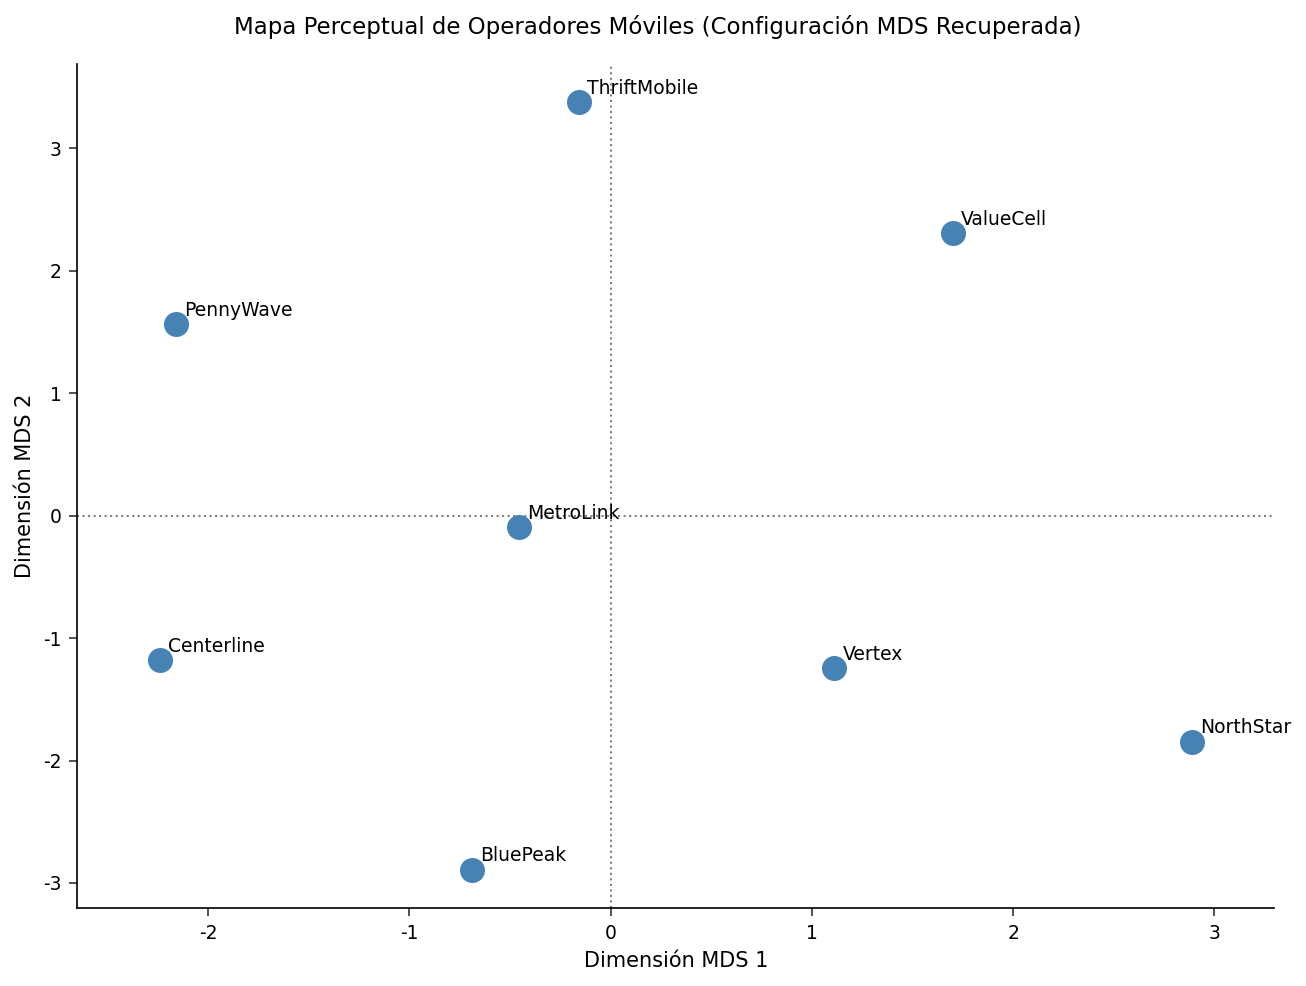

In [3]:
PROC PRINT DATOS=mds_out ETIQUETA;
    ETIQUETA Carrier = "Operador"
          DIM1 = "Dimensión 1"
          DIM2 = "Dimensión 2";
    TÍTULO "Configuración MDS Recuperada (Coordenadas del Objeto)";
EJECUTAR;

PROC PRINT DATOS=mds_fit ETIQUETA;
    TÍTULO "Resumen de Bondad de Ajuste de MDS";
EJECUTAR;

/* Mantener las filas de configuracion y dar a la marca una columna
   de etiqueta con nombre simple para que SGPLOT pueda imprimirla
   junto a cada punto. */
DATOS mds_config;
    ESTABLECER mds_out;
    DONDE _TYPE_ = 'CONFIG';
    LONGITUD Brand $ 12;
    Brand = _NAME_;
    MANTENER Brand DIM1 DIM2;
EJECUTAR;

/* Dibujar el mapa perceptual a partir de las coordenadas recuperadas,
   etiquetando cada marcador con el nombre del operador. */
PROC SGPLOT DATOS=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS label="Dimensión MDS 1";
    YAXIS label="Dimensión MDS 2";
    TÍTULO "Mapa Perceptual de Operadores Móviles (Configuración MDS Recuperada)";
EJECUTAR;


## Paso 4 — Clasificar los sustitutos percibidos

Un resultado práctico para el equipo de marca es, para cada operador, el competidor que se percibe como *más similar* (la menor disimilitud fuera de la diagonal). Reestructuramos la matriz en formato largo y extraemos el vecino más cercano por operador — estos pares son los sustitutos más cercanos y las amenazas competitivas más agudas.

In [4]:
DATOS dissim_long;
    ESTABLECER carrier_dissim;
    LONGITUD Other $ 12;
    ARREGLO d[8] D1-D8;
    ARREGLO nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    HACER j = 1 HASTA 8;
        Other = nm[j];
        Dissimilarity = d[j];
        SI Carrier ne Other ENTONCES SALIDA;
    END;
    MANTENER Carrier Other Dissimilarity;
EJECUTAR;

PROC SORT DATOS=dissim_long;
    POR Carrier Dissimilarity;
EJECUTAR;

DATOS nearest;
    ESTABLECER dissim_long;
    POR Carrier Dissimilarity;
    SI first.Carrier;
EJECUTAR;

PROC PRINT DATOS=nearest noobs ETIQUETA;
    ETIQUETA Carrier = "Operador"
          Other = "Sustituto Percibido Más Cercano"
          Dissimilarity = "Disimilitud";
    TÍTULO "Cada Operador y su Sustituto Percibido Más Cercano";
EJECUTAR;


                                   Cada Operador y su Sustituto Percibido Más Cercano                                   

    Operador   Sustituto Percibido Más Cercano  Disimilitud
BluePeak      Centerline                                  2
Centerline    MetroLink                                 1.9
MetroLink     Vertex                                    1.7
NorthStar     Vertex                                    1.6
PennyWave     MetroLink                                   2
ThriftMobile  ValueCell                                 1.8
ValueCell     ThriftMobile                              1.8
Vertex        NorthStar                                 1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretando los resultados

Debido a que generamos las disimilitudes a partir de una estructura latente genuinamente bidimensional (calidad de red y precio/valor, construidas para variar de forma independiente) más un ruido de encuesta moderado, `PROC MDS` recupera una configuración bidimensional limpia. El criterio de bondad de ajuste se estabiliza alrededor de 1.85 - un ajuste ajustado que confirma que dos dimensiones explican casi toda la estructura percibida.

Leyendo el mapa recuperado (los ejes se identifican solo hasta rotación, reflexión y escala, así que interpretamos direcciones en lugar de signos absolutos):

- **Un eje sigue la calidad de red** - separa a las marcas nacionales premium (NorthStar, Vertex, BluePeak) de los MVNO económicos (ThriftMobile, PennyWave, ValueCell), con MetroLink y Centerline ubicados en el medio.
- **El otro eje sigue el precio/valor** - separa el posicionamiento agresivamente orientado al valor del posicionamiento premium, razón por la cual una marca de alta calidad como BluePeak queda lejos de la igualmente alta calidad NorthStar: comparten reputación de red pero compiten con historias de precio muy diferentes.
- El mapa no muestra un gradiente dominante único: las marcas se distribuyen en los cuatro cuadrantes, por lo que el panorama competitivo es genuinamente bidimensional y no una única línea de premium a económico.

La **tabla de sustitutos más cercanos** convierte el mapa en una lista de acción. El rival percibido más cercano de cada operador es la marca que se ubica junto a él en el mapa - NorthStar y Vertex anclan el rincón premium, ValueCell y ThriftMobile se emparejan en el rincón de valor, y MetroLink aparece como el sustituto más cercano de varias marcas de gama media porque ocupa el centro del mapa. Los pares cercanos señalan rivales directos; las regiones vacías entre grupos resaltan un posicionamiento desocupado que una marca retadora podría atacar.